# Face embedding clustering

This notebook reads face embeddings without changing the database, clusters them with KMeans, and displays the images belonging to each cluster.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image as PILImage
from PIL import ImageDraw
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sqlalchemy import select

from imagelib.db.models import Face, Image
from imagelib.db.session import SessionLocal


## Configuration

In [2]:
n_clusters = 15
random_state = 42

## Load embeddings and image metadata

`SessionLocal` is the project's configured session factory. The context manager materialises the query before closing the session. Embeddings remain aligned with `face_metadata` and the ID/path arrays by their row order.

In [3]:
EMBEDDING_DIMENSIONS = 512


def _embedding_array(value):
    if value is None:
        return None
    if isinstance(value, str):
        try:
            value = json.loads(value)
        except (TypeError, json.JSONDecodeError):
            return None
    try:
        array = np.asarray(value, dtype=np.float64)
    except (TypeError, ValueError):
        return None
    if array.shape != (EMBEDDING_DIMENSIONS,) or not np.all(np.isfinite(array)):
        return None
    return array


with SessionLocal() as session:
    rows = session.execute(
        select(
            Face.id.label("face_id"),
            Face.image_id.label("image_id"),
            Face.x.label("face_x"),
            Face.y.label("face_y"),
            Face.w.label("face_w"),
            Face.h.label("face_h"),
            Face.embedding.label("embedding"),
            Image.path.label("image_path"),
            Image.thumb_path.label("thumb_path"),
            Image.width.label("image_width"),
            Image.height.label("image_height"),
        ).outerjoin(Image, Face.image_id == Image.id)
    ).mappings().all()

In [4]:
vectors = []
face_metadata = []
skipped_embeddings = 0
for row in rows:
    vector = _embedding_array(row["embedding"])
    if vector is None:
        skipped_embeddings += 1
        continue
    vectors.append(vector)
    face_metadata.append(
        {
            "face_id": row["face_id"],
            "image_id": row["image_id"],
            "face_x": row["face_x"],
            "face_y": row["face_y"],
            "face_w": row["face_w"],
            "face_h": row["face_h"],
            "image_path": row["image_path"],
            "thumb_path": row["thumb_path"],
            "image_width": row["image_width"],
            "image_height": row["image_height"],
        }
    )

embeddings = (
    np.vstack(vectors).astype(np.float64, copy=False)
    if vectors
    else np.empty((0, EMBEDDING_DIMENSIONS), dtype=np.float64)
)
face_ids = np.asarray([item["face_id"] for item in face_metadata], dtype=np.int64)
image_ids = np.asarray([item["image_id"] for item in face_metadata], dtype=np.int64)
image_paths = np.asarray([item["image_path"] for item in face_metadata], dtype=object)
thumb_paths = np.asarray([item["thumb_path"] for item in face_metadata], dtype=object)

print(
    f"Loaded {len(embeddings)} numeric embeddings with shape {embeddings.shape}. "
    f"Skipped {skipped_embeddings} NULL or invalid embeddings."
)
embeddings.shape

Loaded 393 numeric embeddings with shape (393, 512). Skipped 0 NULL or invalid embeddings.


(393, 512)

## DBSCAN clustering

In [50]:
sample_count = embeddings.shape[0]
labels = np.empty(0, dtype=np.int64)

clustering = DBSCAN(eps=0.20, min_samples=5, metric='cosine')
labels = clustering.fit_predict(embeddings)
print(f"Computed labels for {sample_count} faces across {len(set(labels))} clusters.")

Computed labels for 393 faces across 10 clusters.


## PCA overview

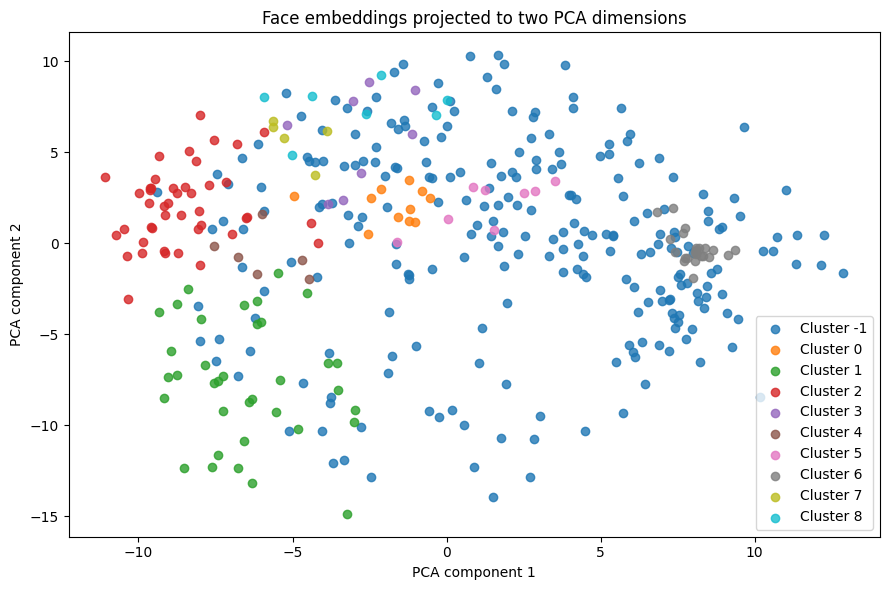

In [51]:
pca_coordinates = np.empty((0, 2), dtype=np.float64)

if sample_count < 2:
    print("PCA needs at least two valid embeddings; overview skipped.")
elif clustering is None:
    print("PCA overview skipped because KMeans did not produce labels.")
else:
    pca = PCA(n_components=2)
    pca_coordinates = pca.fit_transform(embeddings)
    if plt is None:
        print("Matplotlib is unavailable; PCA coordinates are shown instead:")
        print(np.array2string(pca_coordinates, precision=3))
    else:
        figure, axis = plt.subplots(figsize=(9, 6))
        for cluster_id in np.unique(labels):
            cluster_mask = labels == cluster_id
            axis.scatter(
                pca_coordinates[cluster_mask, 0],
                pca_coordinates[cluster_mask, 1],
                label=f"Cluster {cluster_id}",
                alpha=0.8,
            )
        axis.set_title("Face embeddings projected to two PCA dimensions")
        axis.set_xlabel("PCA component 1")
        axis.set_ylabel("PCA component 2")
        axis.legend()
        figure.tight_layout()
        plt.show()

## Cluster image galleries

Thumbnails are preferred and the original path is used as a fallback. Each tile is cropped to its face bounding box. Missing, unreadable, or invalid face crops are represented by a labelled placeholder rather than stopping the gallery.

Cluster 0: 11 faces


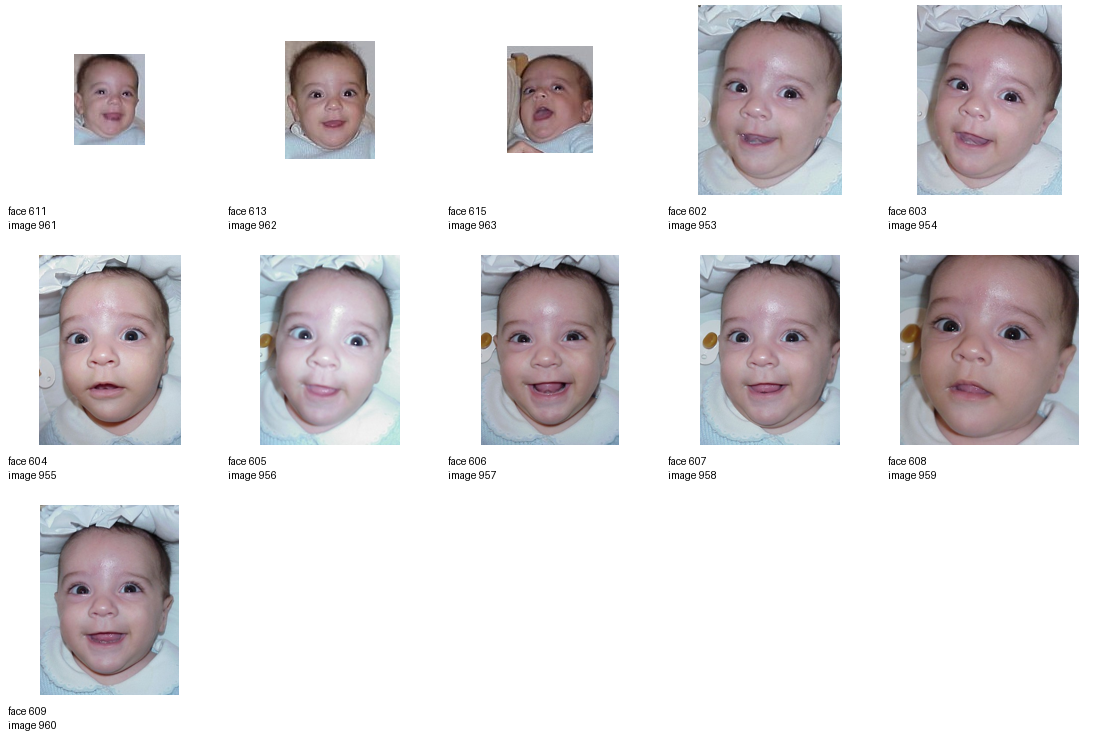

Cluster 1: 36 faces


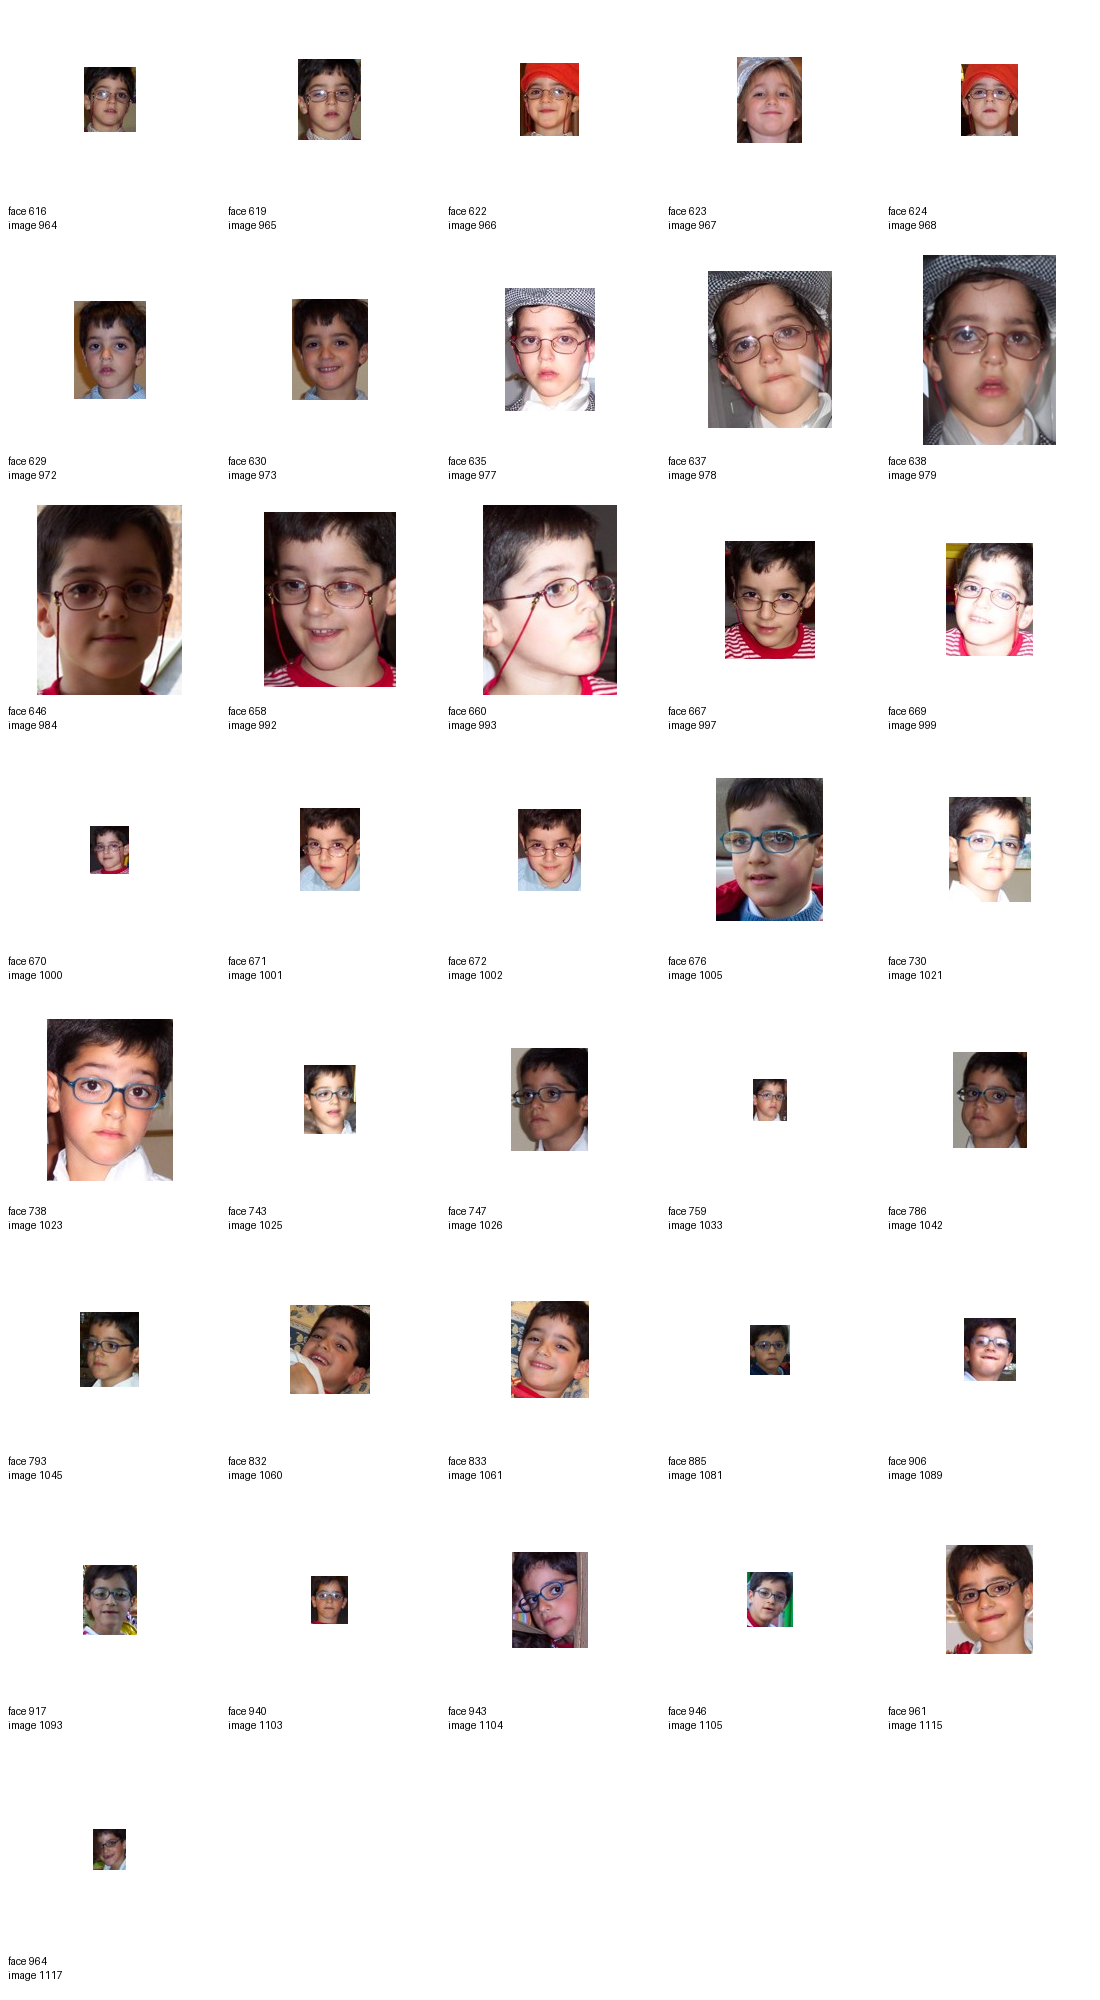

Cluster 2: 44 faces


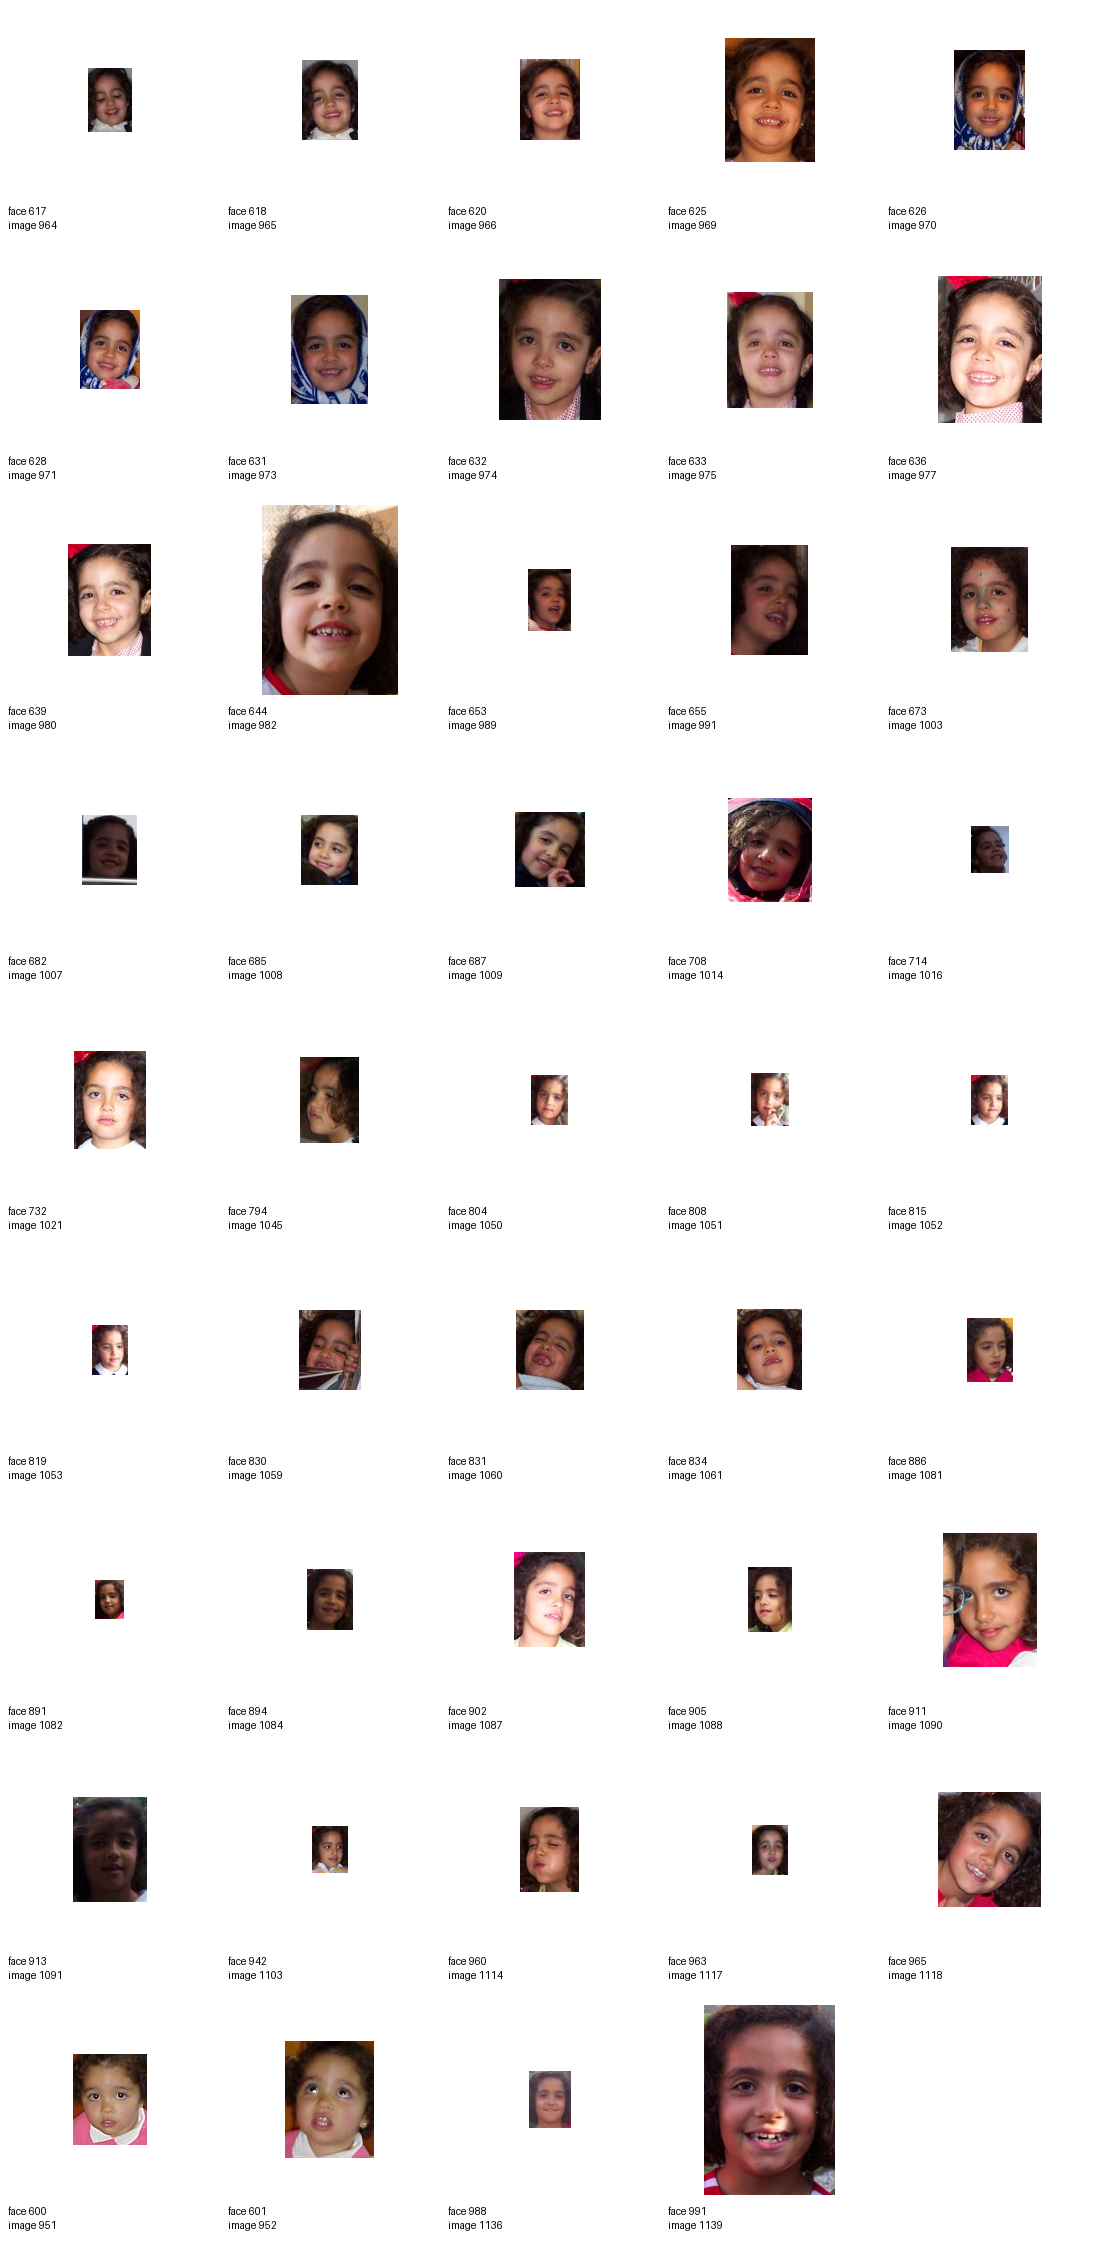

Cluster 3: 8 faces


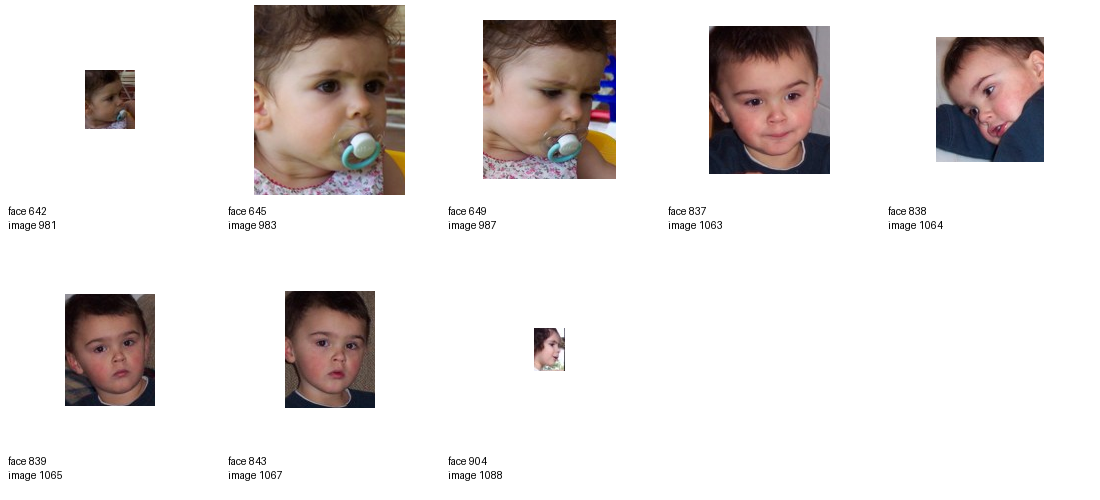

Cluster 4: 6 faces


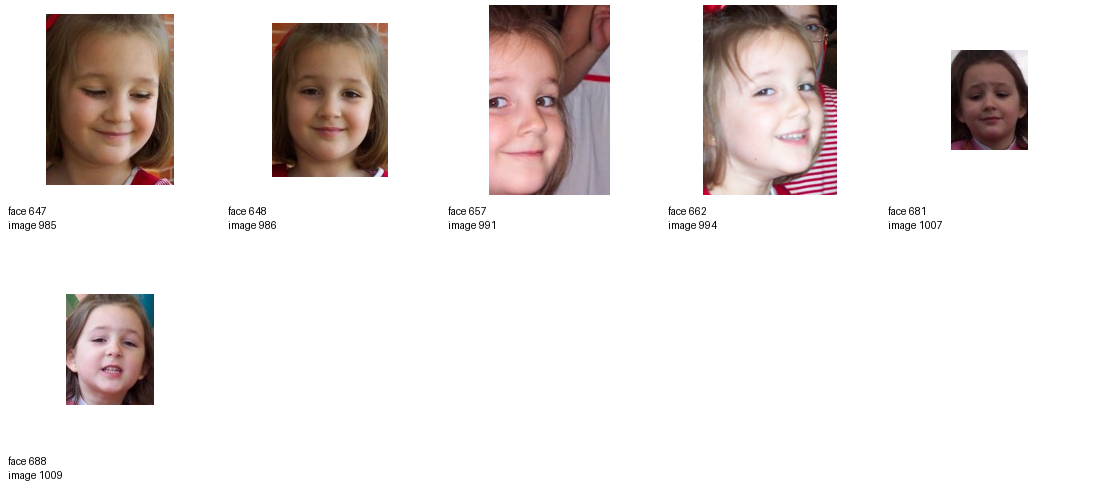

Cluster 5: 8 faces


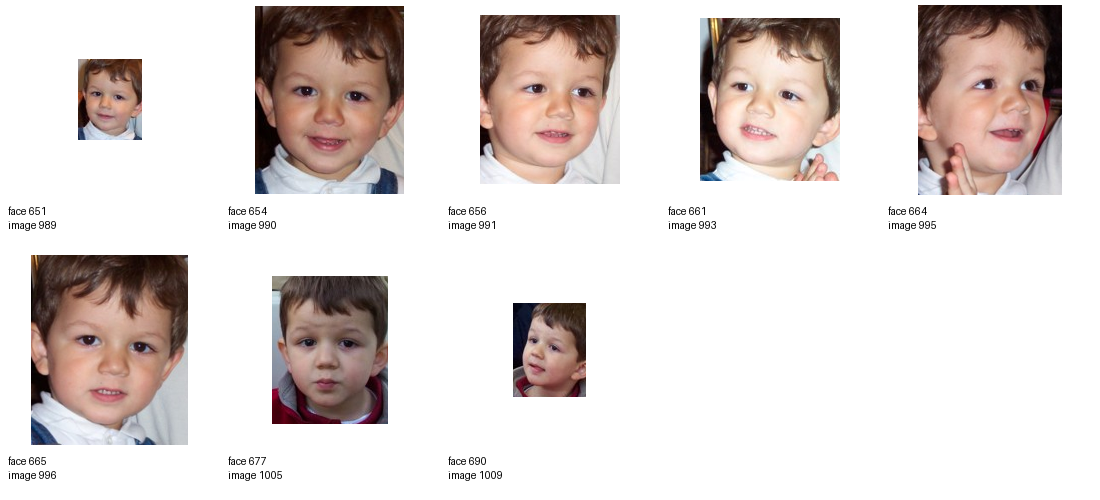

Cluster 6: 23 faces


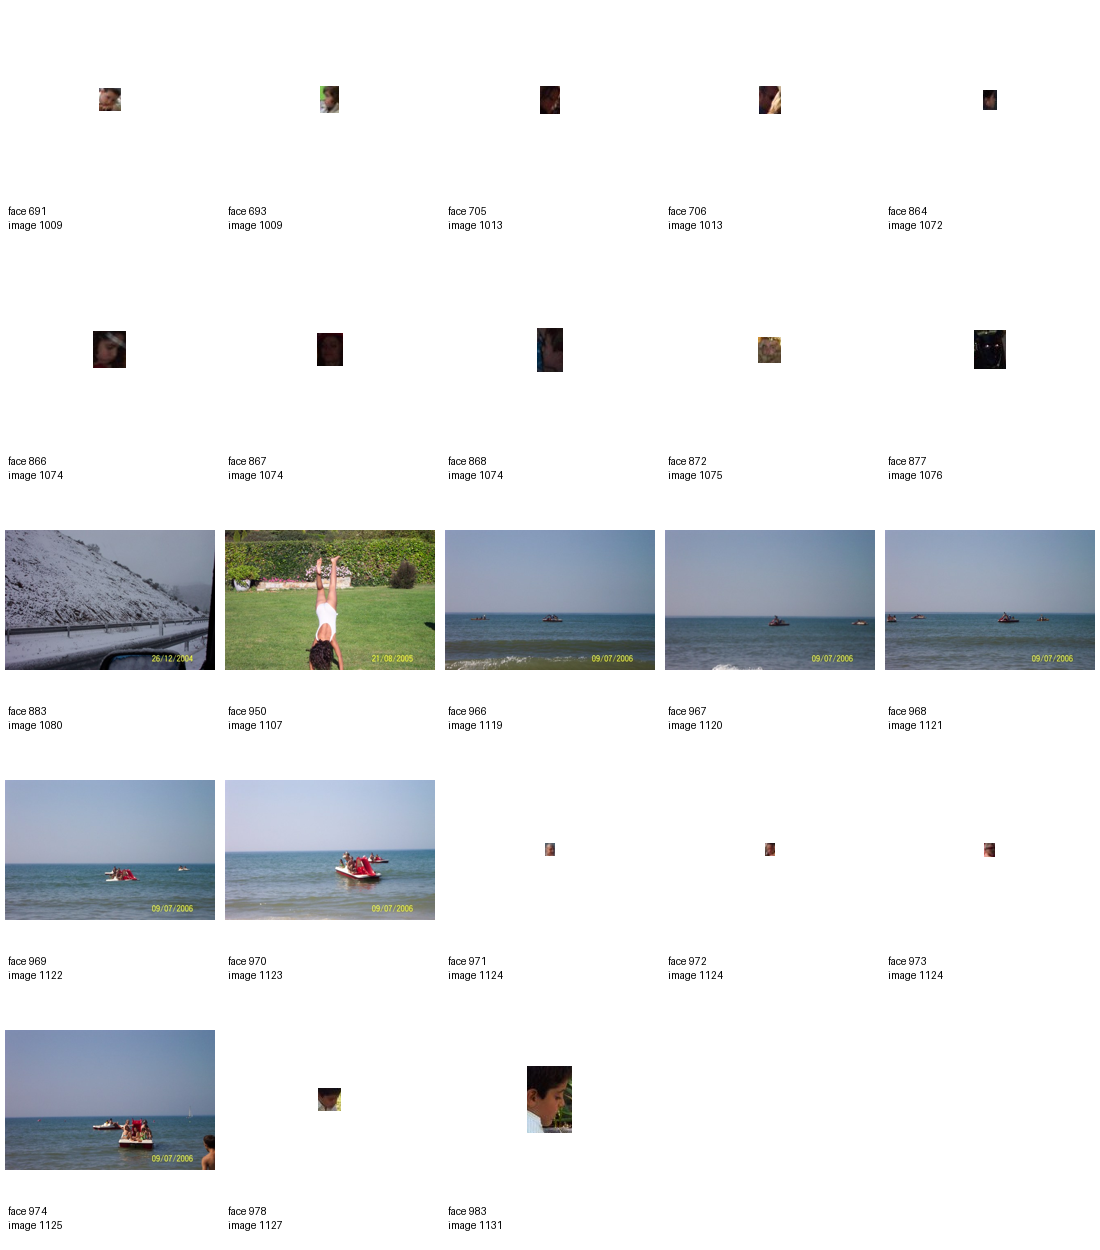

Cluster 7: 5 faces


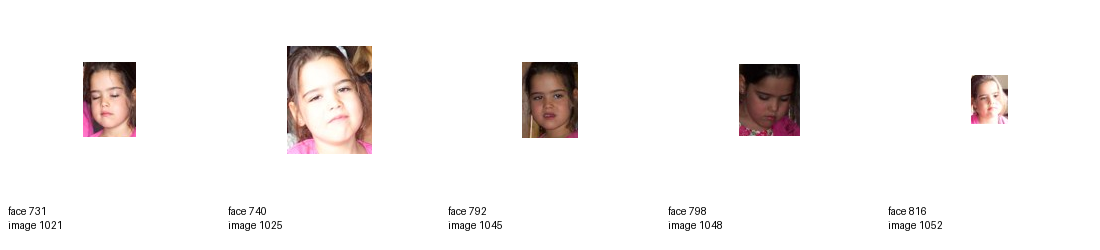

Cluster 8: 7 faces


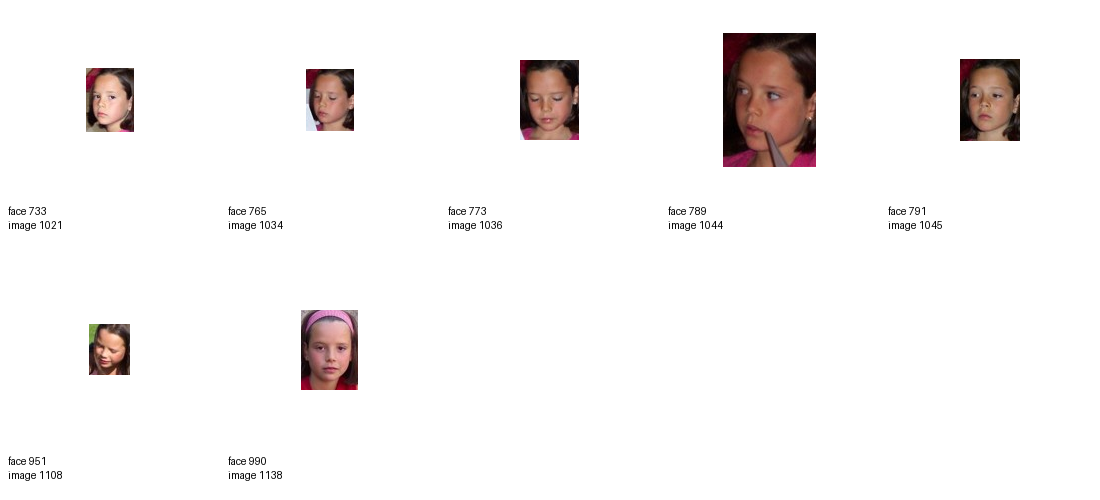

In [52]:
gallery_columns = 5
max_images_per_cluster = None
face_padding = 0.15


def _load_visual(record):
    for key in ("thumb_path", "image_path"):
        raw_path = record.get(key)
        if not raw_path:
            continue
        try:
            candidate = Path(raw_path).expanduser()
            if not candidate.is_file():
                continue
            with PILImage.open(candidate) as image:
                return image.convert("RGB").copy(), candidate
        except (OSError, TypeError, ValueError):
            continue
    return None, None


def _crop_face(image, record, padding=0.15):
    if image is None:
        return None
    try:
        x, y, width, height = (
            float(record[key])
            for key in ("face_x", "face_y", "face_w", "face_h")
        )
        reference_width = float(record.get("image_width") or image.width)
        reference_height = float(record.get("image_height") or image.height)
        padding = max(0.0, float(padding))
    except (TypeError, ValueError, KeyError, OverflowError):
        return None
    if (
        not np.all(np.isfinite((x, y, width, height, reference_width, reference_height, padding)))
        or width <= 0
        or height <= 0
        or reference_width <= 0
        or reference_height <= 0
    ):
        return None

    scale_x = image.width / reference_width
    scale_y = image.height / reference_height
    left = (x - width * padding) * scale_x
    top = (y - height * padding) * scale_y
    right = (x + width * (1 + padding)) * scale_x
    bottom = (y + height * (1 + padding)) * scale_y
    left = max(0, min(image.width, int(np.floor(left))))
    top = max(0, min(image.height, int(np.floor(top))))
    right = max(0, min(image.width, int(np.ceil(right))))
    bottom = max(0, min(image.height, int(np.ceil(bottom))))
    if right <= left or bottom <= top:
        return None
    return image.crop((left, top, right, bottom))


def show_cluster_galleries(cluster_labels, records, columns=5, max_images=None):
    if len(cluster_labels) == 0:
        print("No cluster labels are available; image galleries skipped.")
        return
    if len(cluster_labels) != len(records):
        raise ValueError("Cluster labels and face metadata must have the same length.")
    if columns < 1:
        raise ValueError("gallery_columns must be at least 1.")
    if max_images is not None and max_images < 1:
        raise ValueError("max_images_per_cluster must be None or at least 1.")

    tile_width = 220
    tile_height = 250
    for cluster_id in np.unique(cluster_labels):
        if cluster_id == -1: continue
        indices = np.flatnonzero(cluster_labels == cluster_id)
        shown_indices = indices if max_images is None else indices[:max_images]
        gallery_rows = int(np.ceil(len(shown_indices) / columns))
        sheet = PILImage.new("RGB", (tile_width * columns, tile_height * gallery_rows), "white")
        draw = ImageDraw.Draw(sheet)
        for position, index in enumerate(shown_indices):
            record = records[index]
            image, _source = _load_visual(record)
            crop = _crop_face(image, record, face_padding) if image is not None else None
            column = position % columns
            row = position // columns
            left = column * tile_width
            top = row * tile_height
            if image is None:
                draw.rectangle((left + 5, top + 5, left + tile_width - 5, top + tile_height - 60), fill="#eeeeee")
                draw.text((left + 15, top + 90), f"Image unavailable\nface {record['face_id']}", fill="black")
            elif crop is None:
                draw.rectangle((left + 5, top + 5, left + tile_width - 5, top + tile_height - 60), fill="#eeeeee")
                draw.text((left + 15, top + 90), f"Face crop unavailable\nface {record['face_id']}", fill="black")
            else:
                crop.thumbnail((tile_width - 10, tile_height - 60))
                image_left = left + (tile_width - crop.width) // 2
                image_top = top + (tile_height - 50 - crop.height) // 2
                sheet.paste(crop, (image_left, image_top))
            draw.text((left + 8, top + tile_height - 45), f"face {record['face_id']}\nimage {record['image_id']}", fill="black")
        print(f"Cluster {cluster_id}: {len(indices)} faces")
        if len(shown_indices) < len(indices):
            print(f"Cluster {cluster_id}: omitted {len(indices) - len(shown_indices)} faces.")
        display(sheet)


show_cluster_galleries(
    labels,
    face_metadata,
    columns=gallery_columns,
    max_images=max_images_per_cluster,
)